# AI-Powered Reskilling and Internal Talent Mobility Platform

## Phase 1 — Research-Aligned Data Preparation and Targeted EDA

### Research question
**To what extent can AI-driven reskilling recommendations improve internal job mobility and reduce employee attrition risk?**

This notebook is intentionally limited to steps that directly support the research question and the proposed product:

1. Validate the synthetic HR dataset.
2. Prepare data for predicting internal transition success.
3. Examine factors linked to internal mobility readiness.
4. Examine baseline attrition risk and projected risk reduction.
5. Prevent target leakage before model training.

Unnecessary analyses that do not support the research question are excluded.


## 1. Importing required libraries

In [4]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

## 2. Loading the dataset

In [6]:
DATA_PATH = Path("AI_Internal_Talent_Mobility_Dataset_1200.xlsx")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

excel_file = pd.ExcelFile(DATA_PATH)
print("Available sheets:")
for sheet in excel_file.sheet_names:
    print("-", sheet)


Available sheets:
- Employees
- Internal_Applications
- ML_Training_View
- Role_Requirements
- Course_Mapping
- Quiz_Questions
- Data_Dictionary
- Generation_Notes
- Summary


In [7]:
employees = pd.read_excel(DATA_PATH, sheet_name="Employees")
applications = pd.read_excel(DATA_PATH, sheet_name="Internal_Applications")
ml_data = pd.read_excel(DATA_PATH, sheet_name="ML_Training_View")
roles = pd.read_excel(DATA_PATH, sheet_name="Role_Requirements")
courses = pd.read_excel(DATA_PATH, sheet_name="Course_Mapping")
quizzes = pd.read_excel(DATA_PATH, sheet_name="Quiz_Questions")

print("Employees:", employees.shape)
print("Applications:", applications.shape)
print("ML training view:", ml_data.shape)
print("Roles:", roles.shape)
print("Courses:", courses.shape)
print("Quiz questions:", quizzes.shape)

Employees: (1200, 18)
Applications: (1200, 18)
ML training view: (1200, 32)
Roles: (22, 8)
Courses: (62, 6)
Quiz questions: (110, 7)


## 3. Validating dataset structure

In [8]:
required_ml_columns = {
    "application_id",
    "employee_id",
    "performance_rating",
    "engagement_score",
    "manager_feedback_score",
    "training_hours_last_year",
    "certification_count",
    "prior_internal_moves",
    "baseline_attrition_risk",
    "high_attrition_risk",
    "target_role",
    "skill_match_percentage",
    "experience_gap",
    "role_level_gap",
    "quiz_score",
    "transition_success"
}

missing_required_columns = required_ml_columns.difference(ml_data.columns)

if missing_required_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_required_columns)}")

print("All required research variables are present.")


All required research variables are present.


In [9]:
validation_summary = pd.DataFrame({
    "check": [
        "ML rows",
        "ML columns",
        "Duplicate application IDs",
        "Duplicate employee IDs",
        "Total missing values",
        "Unique transition target values",
        "Unique attrition-risk target values"
    ],
    "result": [
        ml_data.shape[0],
        ml_data.shape[1],
        ml_data["application_id"].duplicated().sum(),
        ml_data["employee_id"].duplicated().sum(),
        int(ml_data.isna().sum().sum()),
        sorted(ml_data["transition_success"].dropna().unique().tolist()),
        sorted(ml_data["high_attrition_risk"].dropna().unique().tolist())
    ]
})

validation_summary

,check,result
0,ML rows,1200
1,ML columns,32
2,Duplicate application IDs,0
3,Duplicate employee IDs,0
4,Total missing values,0
5,Unique transition target values,"[0, 1]"
6,Unique attrition-risk target values,"[0, 1]"


## 4. Inspecting missing values and data types

In [10]:
missing_values = (
    ml_data.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_count")
    .to_frame()
)

missing_values["missing_percentage"] = (
    missing_values["missing_count"] / len(ml_data) * 100
).round(2)

missing_values.head(15)


,missing_count,missing_percentage
application_id,0,0.0
employee_id,0,0.0
age,0,0.0
education_level,0,0.0
current_department,0,0.0
current_role,0,0.0
current_role_level,0,0.0
years_experience,0,0.0
years_in_current_role,0,0.0
performance_rating,0,0.0


In [11]:
ml_data.dtypes.to_frame("data_type")


,data_type
application_id,str
employee_id,str
age,int64
education_level,str
current_department,str
current_role,str
current_role_level,int64
years_experience,int64
years_in_current_role,int64
performance_rating,float64


## 5. Checking target balance

The primary target is `transition_success`, which represents whether an employee successfully transitions into the target internal role.

In [12]:
transition_distribution = (
    ml_data["transition_success"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Unsuccessful transition", 1: "Successful transition"})
    .to_frame("count")
)

transition_distribution["percentage"] = (
    transition_distribution["count"] / len(ml_data) * 100
).round(2)

transition_distribution

,count,percentage
transition_success,,
Unsuccessful transition,785,65.42
Successful transition,415,34.58


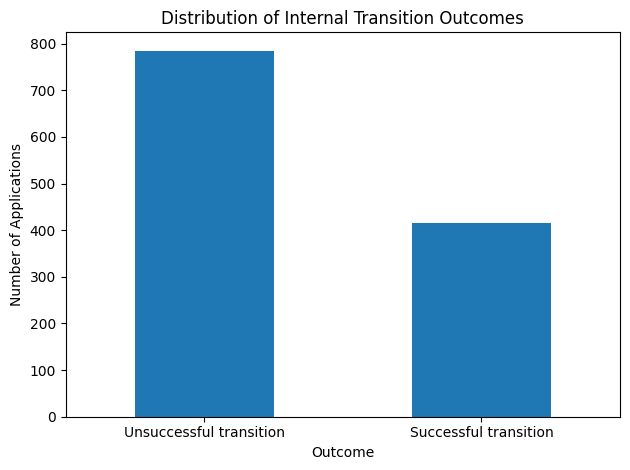

In [13]:
transition_distribution["count"].plot(kind="bar")
plt.title("Distribution of Internal Transition Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Number of Applications")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 6. Preventing target leakage

In [14]:
leakage_columns = [
    "application_id",
    "employee_id",
    "transition_success_probability",
    "projected_attrition_risk_after_reskilling",
    "projected_attrition_risk_reduction",
    "transition_success"
]

present_leakage_columns = [col for col in leakage_columns if col in ml_data.columns]
print("Columns excluded from the transition-success feature set:")
for col in present_leakage_columns:
    print("-", col)


Columns excluded from the transition-success feature set:
- application_id
- employee_id
- projected_attrition_risk_after_reskilling
- projected_attrition_risk_reduction
- transition_success


## 7. Research-aligned exploratory analysis:

In [15]:
key_numeric_features = [
    "skill_match_percentage",
    "quiz_score",
    "performance_rating",
    "engagement_score",
    "manager_feedback_score",
    "training_hours_last_year",
    "certification_count",
    "years_experience",
    "experience_gap",
    "role_level_gap",
    "baseline_attrition_risk"
]

summary_by_transition = (
    ml_data.groupby("transition_success")[key_numeric_features]
    .mean()
    .T
    .rename(columns={0: "Unsuccessful", 1: "Successful"})
)

summary_by_transition["Difference"] = (
    summary_by_transition["Successful"] - summary_by_transition["Unsuccessful"]
)

summary_by_transition.round(2)


transition_success,Unsuccessful,Successful,Difference
skill_match_percentage,45.21,65.95,20.74
quiz_score,62.43,73.41,10.98
performance_rating,3.36,3.54,0.17
engagement_score,67.30,68.66,1.36
manager_feedback_score,3.51,3.67,0.16
training_hours_last_year,32.47,35.64,3.16
certification_count,1.06,1.37,0.31
years_experience,5.48,5.81,0.32
experience_gap,-1.63,-2.33,-0.69
role_level_gap,1.62,1.42,-0.20


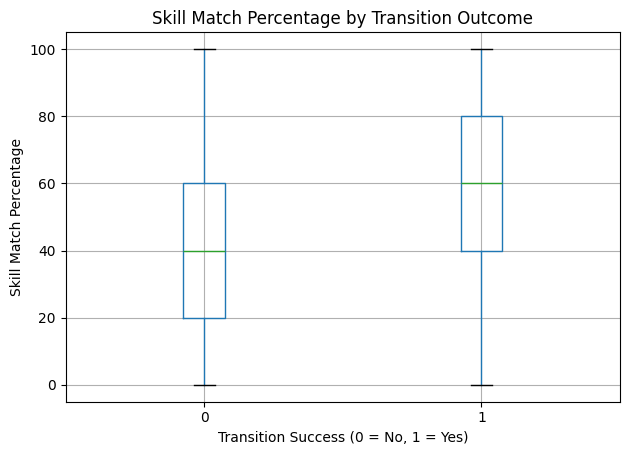

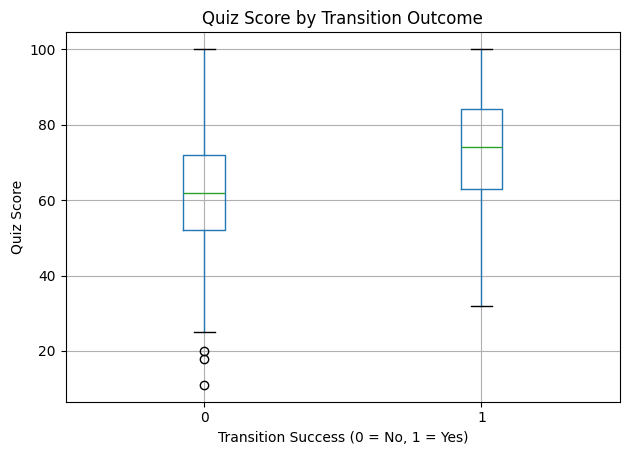

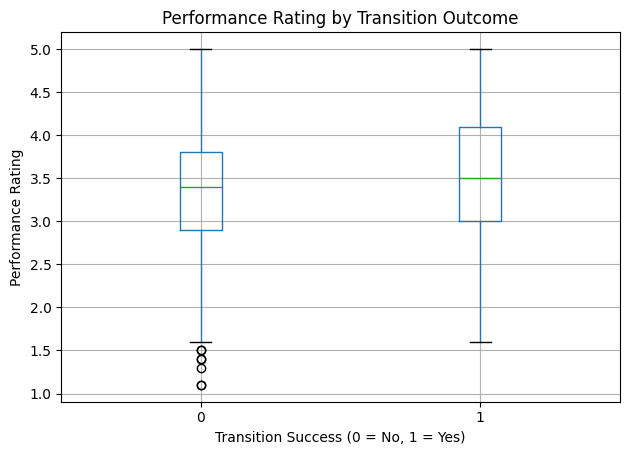

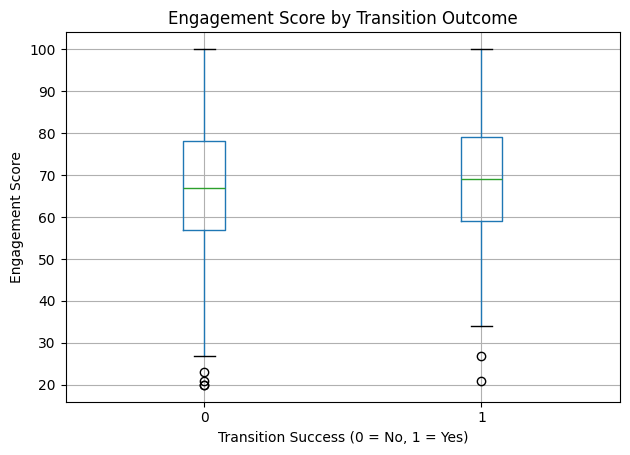

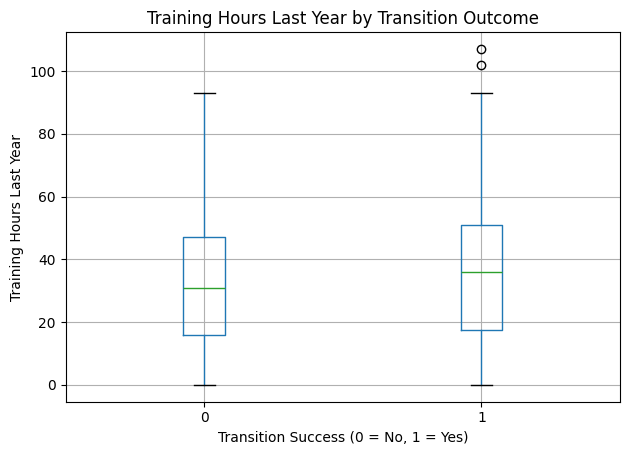

In [16]:
selected_features = [
    "skill_match_percentage",
    "quiz_score",
    "performance_rating",
    "engagement_score",
    "training_hours_last_year"
]

for feature in selected_features:
    ml_data.boxplot(column=feature, by="transition_success")
    plt.title(f"{feature.replace('_', ' ').title()} by Transition Outcome")
    plt.suptitle("")
    plt.xlabel("Transition Success (0 = No, 1 = Yes)")
    plt.ylabel(feature.replace("_", " ").title())
    plt.tight_layout()
    plt.show()


## 8. Skill match and reskilling need

Skill match is central to the platform because missing skills will be converted into personalised course recommendations.

In [17]:
skill_match_bins = pd.cut(
    ml_data["skill_match_percentage"],
    bins=[-0.01, 39.99, 59.99, 79.99, 100],
    labels=["Below 40%", "40–59%", "60–79%", "80–100%"]
)

skill_match_outcomes = pd.crosstab(
    skill_match_bins,
    ml_data["transition_success"],
    normalize="index"
).rename(columns={0: "Unsuccessful rate", 1: "Successful rate"})

skill_match_outcomes.round(3)


transition_success,Unsuccessful rate,Successful rate
skill_match_percentage,,
Below 40%,0.900,0.100
40–59%,0.739,0.261
60–79%,0.646,0.354
80–100%,0.368,0.632


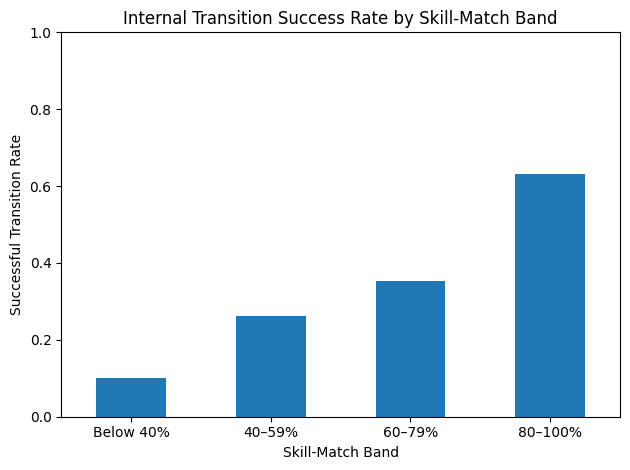

In [18]:
skill_match_outcomes["Successful rate"].plot(kind="bar")
plt.title("Internal Transition Success Rate by Skill-Match Band")
plt.xlabel("Skill-Match Band")
plt.ylabel("Successful Transition Rate")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 9. Attrition-risk analysis

In [22]:
attrition_summary = pd.DataFrame({
    "Metric": [
        "Average baseline attrition risk",
        "Average projected attrition risk after reskilling",
        "Average projected risk reduction",
        "Employees classified as high attrition risk"
    ],
    "Value": [
        employees["baseline_attrition_risk"].mean(),
        applications["projected_attrition_risk_after_reskilling"].mean(),
        applications["projected_attrition_risk_reduction"].mean(),
        employees["high_attrition_risk"].sum()
    ]
})

attrition_summary

,Metric,Value
0,Average baseline attrition risk,0.312287
1,Average projected attrition risk after reskilling,0.250834
2,Average projected risk reduction,0.061452
3,Employees classified as high attrition risk,166.000000


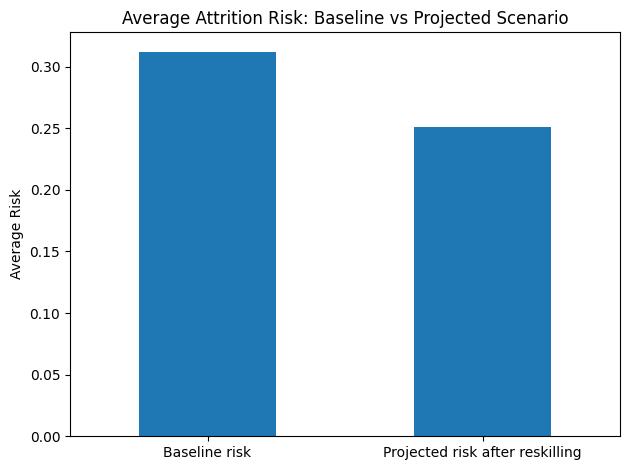

In [23]:
risk_comparison = pd.DataFrame({
    "Baseline risk": employees["baseline_attrition_risk"],
    "Projected risk after reskilling": applications["projected_attrition_risk_after_reskilling"]
})

risk_comparison.mean().plot(kind="bar")
plt.title("Average Attrition Risk: Baseline vs Projected Scenario")
plt.ylabel("Average Risk")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 10. Preparing the modelling dataset

In [24]:
target_column = "transition_success"

excluded_columns = [
    "application_id",
    "employee_id",
    "transition_success_probability",
    "projected_attrition_risk_after_reskilling",
    "projected_attrition_risk_reduction",
    target_column
]

X = ml_data.drop(columns=[c for c in excluded_columns if c in ml_data.columns]).copy()
y = ml_data[target_column].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Target mean:", round(y.mean(), 4))


Feature matrix shape: (1200, 27)
Target shape: (1200,)
Target mean: 0.3458


In [25]:
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumeric features:")
print(numeric_features)


Categorical features:
['education_level', 'current_department', 'current_role', 'salary_band', 'target_department', 'target_role', 'application_status']

Numeric features:
['age', 'current_role_level', 'years_experience', 'years_in_current_role', 'performance_rating', 'engagement_score', 'manager_feedback_score', 'training_hours_last_year', 'certification_count', 'prior_internal_moves', 'baseline_attrition_risk', 'high_attrition_risk', 'target_role_level', 'skill_overlap_count', 'required_skill_count', 'skill_match_percentage', 'minimum_experience', 'experience_gap', 'role_level_gap', 'quiz_score']


In [26]:
# Final research-aligned features for predicting internal transition success

transition_features = [
    "age",
    "education_level",
    "current_department",
    "current_role",
    "current_role_level",
    "years_experience",
    "years_in_current_role",
    "performance_rating",
    "engagement_score",
    "manager_feedback_score",
    "training_hours_last_year",
    "certification_count",
    "prior_internal_moves",
    "salary_band",
    "target_department",
    "target_role",
    "target_role_level",
    "skill_overlap_count",
    "required_skill_count",
    "skill_match_percentage",
    "minimum_experience",
    "experience_gap",
    "role_level_gap",
    "quiz_score"
]

X = ml_data[transition_features].copy()
y = ml_data["transition_success"].copy()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Final feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nCategorical features:")
print(categorical_features)

print("\nNumeric features:")
print(numeric_features)

print("\nTarget distribution:")
print(y.value_counts())
print("\nTarget percentages:")
print((y.value_counts(normalize=True) * 100).round(2))

Final feature matrix shape: (1200, 24)
Target shape: (1200,)

Categorical features:
['education_level', 'current_department', 'current_role', 'salary_band', 'target_department', 'target_role']

Numeric features:
['age', 'current_role_level', 'years_experience', 'years_in_current_role', 'performance_rating', 'engagement_score', 'manager_feedback_score', 'training_hours_last_year', 'certification_count', 'prior_internal_moves', 'target_role_level', 'skill_overlap_count', 'required_skill_count', 'skill_match_percentage', 'minimum_experience', 'experience_gap', 'role_level_gap', 'quiz_score']

Target distribution:
transition_success
0    785
1    415
Name: count, dtype: int64

Target percentages:
transition_success
0    65.42
1    34.58
Name: proportion, dtype: float64


## 11.  Splitting the Dataset into Training and Testing Sets

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Feature Set :", X_train.shape)
print("Testing Feature Set  :", X_test.shape)

print("\nTraining Target Distribution")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting Target Distribution")
print(y_test.value_counts(normalize=True).round(3))

Training Feature Set : (960, 24)
Testing Feature Set  : (240, 24)

Training Target Distribution
transition_success
0    0.654
1    0.346
Name: proportion, dtype: float64

Testing Target Distribution
transition_success
0    0.654
1    0.346
Name: proportion, dtype: float64


## 12. Creating the Data Pre-processing Pipeline

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocessing numerical features
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# Preprocessing categorical features
categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combining both preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Pre-processing pipeline created successfully.")

print("\nNumber of Numerical Features :", len(numeric_features))
print("Number of Categorical Features:", len(categorical_features))

print("\nNumerical Features")
print(numeric_features)

print("\nCategorical Features")
print(categorical_features)

Pre-processing pipeline created successfully.

Number of Numerical Features : 18
Number of Categorical Features: 6

Numerical Features
['age', 'current_role_level', 'years_experience', 'years_in_current_role', 'performance_rating', 'engagement_score', 'manager_feedback_score', 'training_hours_last_year', 'certification_count', 'prior_internal_moves', 'target_role_level', 'skill_overlap_count', 'required_skill_count', 'skill_match_percentage', 'minimum_experience', 'experience_gap', 'role_level_gap', 'quiz_score']

Categorical Features
['education_level', 'current_department', 'current_role', 'salary_band', 'target_department', 'target_role']


## 13. Creating Machine Learning Pipelines

In [31]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

# Dictionary containing all machine learning models
models = {

    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=200
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "Support Vector Machine": SVC(
        probability=True,
        random_state=42
    )

}

# Creating a preprocessing + model pipeline for every algorithm

pipelines = {}

for model_name, model in models.items():

    pipelines[model_name] = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

print("Machine Learning Pipelines Created Successfully.\n")

print("Models selected for comparison:")

for model in pipelines.keys():
    print("•", model)

Machine Learning Pipelines Created Successfully.

Models selected for comparison:
• Logistic Regression
• Decision Tree
• Random Forest
• Gradient Boosting
• Support Vector Machine


## 14. Training and Evaluating Machine Learning Models

In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for model_name, pipeline in pipelines.items():

    print("=" * 70)
    print(f"Training {model_name}...")
    
    # Training the model
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)

    # Probability predictions (required for ROC-AUC)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": model_name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4)
    })

# Creating comparison table
results_df = (
    pd.DataFrame(results)
    .sort_values(by="F1-Score", ascending=False)
    .reset_index(drop=True)
)

print("\nModel Performance Comparison")
display(results_df)

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training Support Vector Machine...

Model Performance Comparison


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.6958,0.5625,0.5422,0.5521,0.7475
1,Support Vector Machine,0.7125,0.6207,0.4337,0.5106,0.7411
2,Gradient Boosting,0.6875,0.5571,0.4699,0.5098,0.7207
3,Random Forest,0.6917,0.5738,0.4217,0.4861,0.7352
4,Decision Tree,0.6042,0.4268,0.4217,0.4242,0.5612


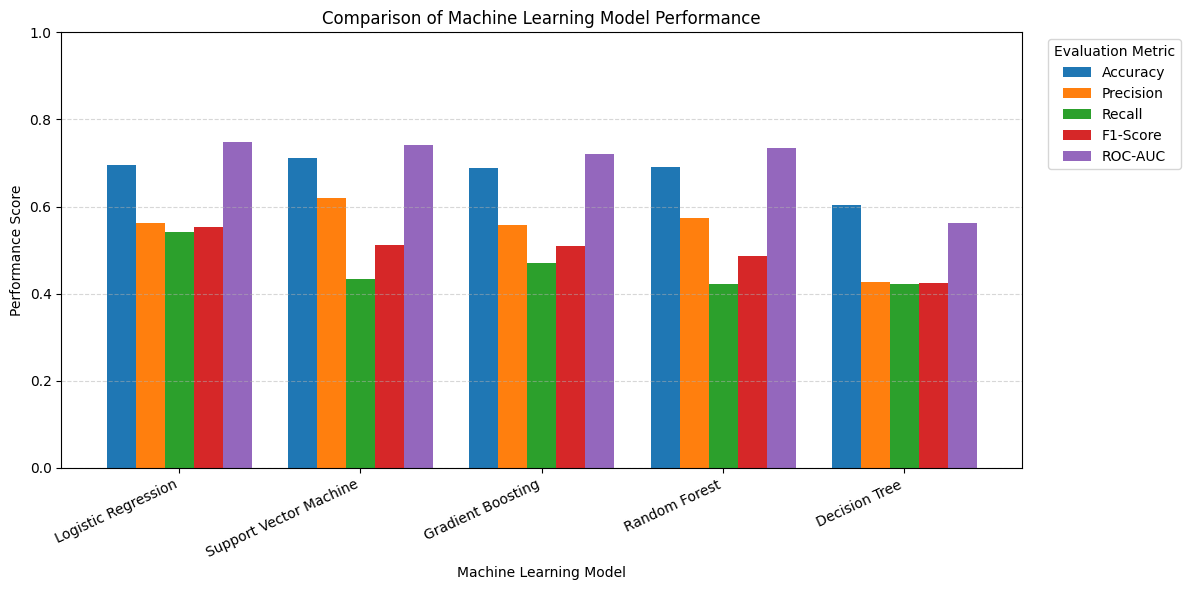

In [35]:
# Visualising Model Performance

plot_results = results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
]

# Creating grouped bar chart
ax = plot_results.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.80
)

plt.title("Comparison of Machine Learning Model Performance")
plt.xlabel("Machine Learning Model")
plt.ylabel("Performance Score")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.legend(
    title="Evaluation Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 15. Cross-Validation of the Three Strongest Models

In [36]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Selecting the three strongest models from the initial comparison
top_model_names = [
    "Logistic Regression",
    "Support Vector Machine",
    "Gradient Boosting"
]

# Stratified 5-fold cross-validation
stratified_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Metrics relevant to the research objective
scoring_metrics = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for model_name in top_model_names:

    print(f"Cross-validating {model_name}...")

    scores = cross_validate(
        pipelines[model_name],
        X_train,
        y_train,
        cv=stratified_cv,
        scoring=scoring_metrics,
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "Mean Accuracy": scores["test_accuracy"].mean(),
        "Mean Precision": scores["test_precision"].mean(),
        "Mean Recall": scores["test_recall"].mean(),
        "Mean F1-Score": scores["test_f1"].mean(),
        "Mean ROC-AUC": scores["test_roc_auc"].mean(),
        "F1 Standard Deviation": scores["test_f1"].std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = (
    cv_results_df
    .sort_values(by="Mean F1-Score", ascending=False)
    .reset_index(drop=True)
)

print("\nFive-Fold Cross-Validation Results:")
display(cv_results_df.round(4))

Cross-validating Logistic Regression...


/Users/admin/Downloads/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/admin/Downloads/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/admin/Downloads/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/admin/Downloads/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (v

Cross-validating Support Vector Machine...
Cross-validating Gradient Boosting...

Five-Fold Cross-Validation Results:


,Model,Mean Accuracy,Mean Precision,Mean Recall,Mean F1-Score,Mean ROC-AUC,F1 Standard Deviation
0,Logistic Regression,0.7073,0.5994,0.4667,0.5243,0.7317,0.0510
1,Support Vector Machine,0.7177,0.6457,0.4186,0.5072,0.7397,0.0402
2,Gradient Boosting,0.6896,0.5659,0.4457,0.4978,0.7157,0.0311


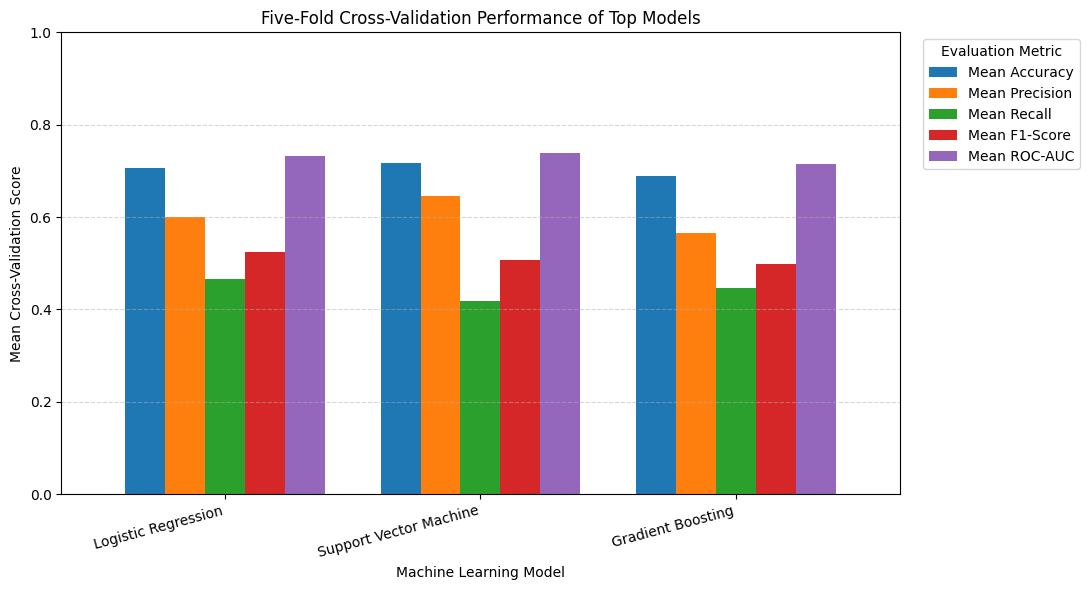

In [37]:
# Visualising Cross-Validation Performance

cv_plot_data = cv_results_df.set_index("Model")[
    [
        "Mean Accuracy",
        "Mean Precision",
        "Mean Recall",
        "Mean F1-Score",
        "Mean ROC-AUC"
    ]
]

ax = cv_plot_data.plot(
    kind="bar",
    figsize=(11, 6),
    width=0.78
)

plt.title("Five-Fold Cross-Validation Performance of Top Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Mean Cross-Validation Score")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.legend(
    title="Evaluation Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 16. Hyperparameter Tuning for Logistic Regression

In [38]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid for Logistic Regression
logistic_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__class_weight": [None, "balanced"],
    "classifier__solver": ["liblinear", "lbfgs"]
}

# Grid search using the existing Logistic Regression pipeline
logistic_grid_search = GridSearchCV(
    estimator=pipelines["Logistic Regression"],
    param_grid=logistic_param_grid,
    scoring="f1",
    cv=stratified_cv,
    n_jobs=-1,
    verbose=1
)

# Training all parameter combinations
logistic_grid_search.fit(X_train, y_train)

print("Best Logistic Regression Parameters:")
print(logistic_grid_search.best_params_)

print("\nBest Mean Cross-Validated F1-Score:")
print(round(logistic_grid_search.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Users/admin/Downloads/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/admin/Downloads/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/admin/Downloads/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/admin/Downloads/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (v

Best Logistic Regression Parameters:
{'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__solver': 'lbfgs'}

Best Mean Cross-Validated F1-Score:
0.606


## 17. Evaluating the Tuned Logistic Regression Model

In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Retrieving the best tuned Logistic Regression pipeline
tuned_logistic_model = logistic_grid_search.best_estimator_

# Predicting outcomes on unseen test data
tuned_logistic_predictions = tuned_logistic_model.predict(X_test)

# Predicting probabilities of successful transition
tuned_logistic_probabilities = tuned_logistic_model.predict_proba(X_test)[:, 1]

# Calculating test-set metrics
tuned_logistic_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Tuned Logistic Regression": [
        accuracy_score(y_test, tuned_logistic_predictions),
        precision_score(
            y_test,
            tuned_logistic_predictions,
            zero_division=0
        ),
        recall_score(
            y_test,
            tuned_logistic_predictions,
            zero_division=0
        ),
        f1_score(
            y_test,
            tuned_logistic_predictions,
            zero_division=0
        ),
        roc_auc_score(
            y_test,
            tuned_logistic_probabilities
        )
    ]
})

print("Tuned Logistic Regression Test Performance:")
display(tuned_logistic_results.round(4))

Tuned Logistic Regression Test Performance:


,Metric,Tuned Logistic Regression
0,Accuracy,0.6583
1,Precision,0.5040
2,Recall,0.7590
3,F1-Score,0.6058
4,ROC-AUC,0.7495


## 18. Comparing Original and Tuned Logistic Regression

In [40]:
original_logistic_results = results_df[
    results_df["Model"] == "Logistic Regression"
][
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
].iloc[0]

logistic_comparison = pd.DataFrame({
    "Original Logistic Regression": original_logistic_results.values,
    "Tuned Logistic Regression": tuned_logistic_results[
        "Tuned Logistic Regression"
    ].values
},
index=[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
])

display(logistic_comparison.round(4))

,Original Logistic Regression,Tuned Logistic Regression
Accuracy,0.6958,0.6583
Precision,0.5625,0.5040
Recall,0.5422,0.7590
F1-Score,0.5521,0.6058
ROC-AUC,0.7475,0.7495


## 19. Visualising Original vs Tuned Logistic Regression

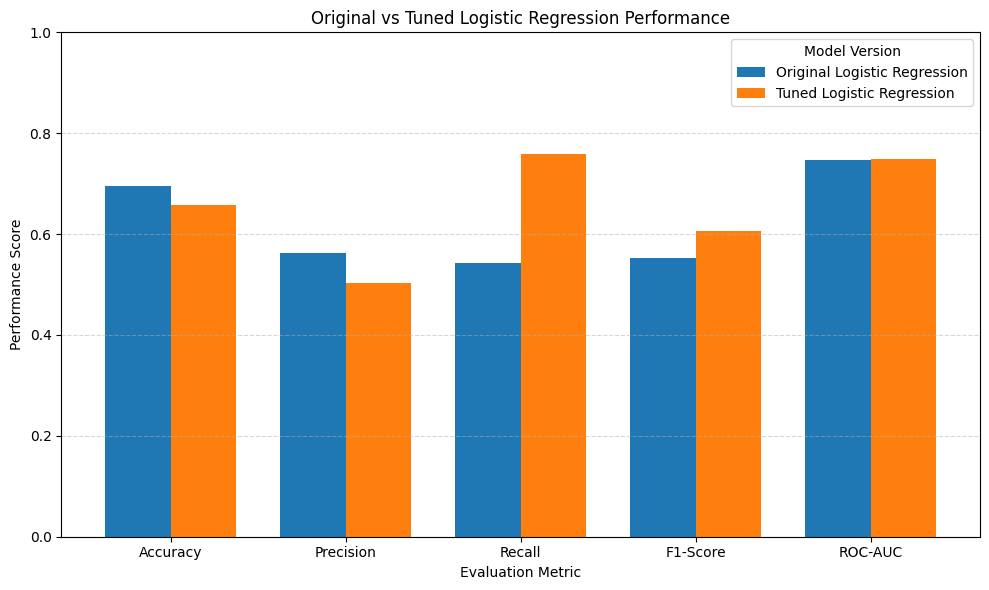

In [41]:
ax = logistic_comparison.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)

plt.title("Original vs Tuned Logistic Regression Performance")
plt.xlabel("Evaluation Metric")
plt.ylabel("Performance Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model Version")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 20. Hyperparameter Tuning for Support Vector Machine

In [42]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid for SVM
svm_param_grid = {
    "classifier__C": [0.1, 1, 10],
    "classifier__kernel": ["linear", "rbf"],
    "classifier__gamma": ["scale", "auto"],
    "classifier__class_weight": [None, "balanced"]
}

# Grid search using the existing SVM pipeline
svm_grid_search = GridSearchCV(
    estimator=pipelines["Support Vector Machine"],
    param_grid=svm_param_grid,
    scoring="f1",
    cv=stratified_cv,
    n_jobs=-1,
    verbose=1
)

# Training all parameter combinations
svm_grid_search.fit(X_train, y_train)

print("Best Support Vector Machine Parameters:")
print(svm_grid_search.best_params_)

print("\nBest Mean Cross-Validated F1-Score:")
print(round(svm_grid_search.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/Users/admin/Downloads/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/admin/Downloads/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/admin/Downloads/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/admin/Downloads/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (v

Best Support Vector Machine Parameters:
{'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf'}

Best Mean Cross-Validated F1-Score:
0.5992


## 21. Evaluating the Tuned Support Vector Machine

In [43]:
# Retrieving the best tuned SVM pipeline
tuned_svm_model = svm_grid_search.best_estimator_

# Predicting transition outcomes on the unseen test dataset
tuned_svm_predictions = tuned_svm_model.predict(X_test)

# Predicting probabilities of successful transition
tuned_svm_probabilities = tuned_svm_model.predict_proba(X_test)[:, 1]

# Calculating evaluation metrics
tuned_svm_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Tuned Support Vector Machine": [
        accuracy_score(y_test, tuned_svm_predictions),
        precision_score(
            y_test,
            tuned_svm_predictions,
            zero_division=0
        ),
        recall_score(
            y_test,
            tuned_svm_predictions,
            zero_division=0
        ),
        f1_score(
            y_test,
            tuned_svm_predictions,
            zero_division=0
        ),
        roc_auc_score(
            y_test,
            tuned_svm_probabilities
        )
    ]
})

print("Tuned Support Vector Machine Test Performance:")
display(tuned_svm_results.round(4))

Tuned Support Vector Machine Test Performance:


,Metric,Tuned Support Vector Machine
0,Accuracy,0.6583
1,Precision,0.5042
2,Recall,0.7229
3,F1-Score,0.5941
4,ROC-AUC,0.7438


## 22. Comparing Tuned Logistic Regression and Tuned SVM

In [44]:
tuned_model_comparison = pd.DataFrame({
    "Tuned Logistic Regression":
        tuned_logistic_results["Tuned Logistic Regression"].values,

    "Tuned Support Vector Machine":
        tuned_svm_results["Tuned Support Vector Machine"].values
},
index=[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
])

print("Final Tuned Model Comparison:")
display(tuned_model_comparison.round(4))

Final Tuned Model Comparison:


,Tuned Logistic Regression,Tuned Support Vector Machine
Accuracy,0.6583,0.6583
Precision,0.5040,0.5042
Recall,0.7590,0.7229
F1-Score,0.6058,0.5941
ROC-AUC,0.7495,0.7438


## 23. Visualising the Tuned Model Comparison

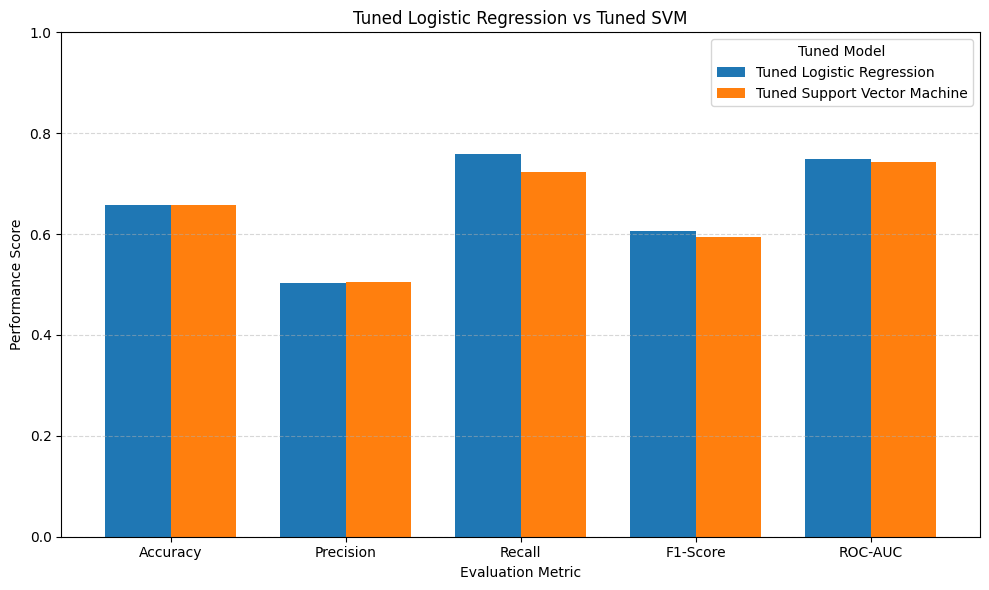

In [45]:
ax = tuned_model_comparison.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)

plt.title("Tuned Logistic Regression vs Tuned SVM")
plt.xlabel("Evaluation Metric")
plt.ylabel("Performance Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Tuned Model")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 24. Confusion Matrix for Final Logistic Regression

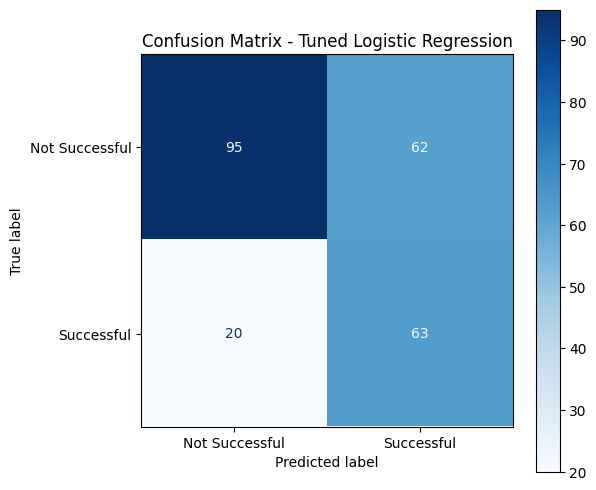

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    tuned_logistic_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Successful", "Successful"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax
)

plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.grid(False)
plt.show()

## 25. Classification Report

In [47]:
from sklearn.metrics import classification_report

print("Classification Report")
print("="*60)

print(
    classification_report(
        y_test,
        tuned_logistic_predictions,
        target_names=[
            "Not Successful",
            "Successful"
        ]
    )
)

Classification Report
                precision    recall  f1-score   support

Not Successful       0.83      0.61      0.70       157
    Successful       0.50      0.76      0.61        83

      accuracy                           0.66       240
     macro avg       0.67      0.68      0.65       240
  weighted avg       0.71      0.66      0.67       240



## 26. ROC Curve

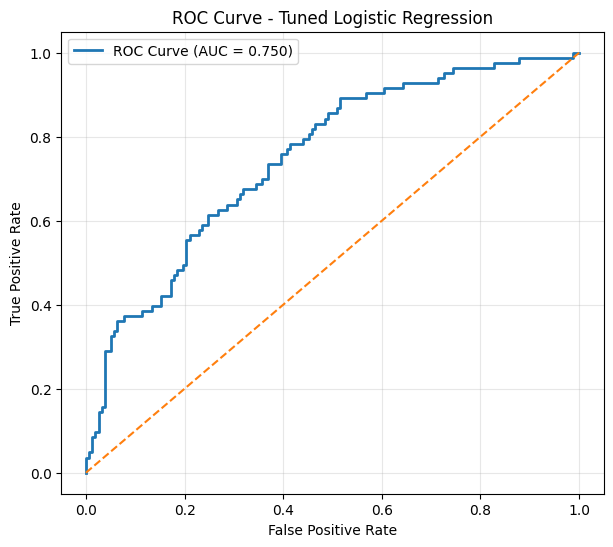

In [48]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(
    y_test,
    tuned_logistic_probabilities
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC Curve (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 27. Explaining the Final Logistic Regression Model

In [49]:
# Retrieving the fitted preprocessing component
fitted_preprocessor = tuned_logistic_model.named_steps["preprocessor"]

# Retrieving the fitted Logistic Regression classifier
final_logistic_classifier = tuned_logistic_model.named_steps["classifier"]

# Getting the transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Getting the model coefficients
coefficients = final_logistic_classifier.coef_[0]

# Creating a coefficient table
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute Importance": np.abs(coefficients)
})

# Sorting by absolute importance
feature_importance_df = (
    feature_importance_df
    .sort_values(by="Absolute Importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 Most Influential Features:")
display(feature_importance_df.head(20).round(4))

Top 20 Most Influential Features:


,Feature,Coefficient,Absolute Importance
0,num__skill_match_percentage,0.3321,0.3321
1,num__skill_overlap_count,0.3263,0.3263
2,num__quiz_score,0.2659,0.2659
3,num__performance_rating,0.1483,0.1483
4,num__certification_count,0.1440,0.1440
5,num__minimum_experience,-0.1204,0.1204
6,num__engagement_score,0.1187,0.1187
7,num__manager_feedback_score,0.0964,0.0964
8,num__age,-0.0856,0.0856
9,num__experience_gap,-0.0821,0.0821


## 28. Preparing the AI Recommendation Engine

In [51]:
# Loading Data for the AI Recommendation Engine

employees = pd.read_excel(
    excel_file,
    sheet_name="Employees"
)

roles = pd.read_excel(
    excel_file,
    sheet_name="Role_Requirements"
)

courses = pd.read_excel(
    excel_file,
    sheet_name="Course_Mapping"
)

print("="*60)
print("AI Recommendation Data Loaded Successfully")
print("="*60)

print("\nEmployees:", employees.shape)
print("Roles:", roles.shape)
print("Courses:", courses.shape)

print("\nEmployee Columns")
display(pd.DataFrame(employees.columns, columns=["Column"]))

print("\nRole Requirement Columns")
display(pd.DataFrame(roles.columns, columns=["Column"]))

print("\nCourse Mapping Columns")
display(pd.DataFrame(courses.columns, columns=["Column"]))

AI Recommendation Data Loaded Successfully

Employees: (1200, 18)
Roles: (22, 8)
Courses: (62, 6)

Employee Columns


,Column
0,employee_id
1,age
2,education_level
3,current_department
4,current_role
5,current_role_level
6,years_experience
7,years_in_current_role
8,performance_rating
9,engagement_score



Role Requirement Columns


,Column
0,role_id
1,department
2,role_name
3,role_level
4,minimum_experience
5,required_skills
6,preferred_certifications
7,assessment_category



Course Mapping Columns


,Column
0,skill
1,recommended_course
2,course_level
3,estimated_hours
4,provider
5,certificate_available


## 29. Building the AI Skill-Matching and Role-Ranking Engine

In [52]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity

# Function to convert comma-separated skills into clean lists

def parse_skills(skill_text):
    if pd.isna(skill_text):
        return []

    return [
        skill.strip()
        for skill in str(skill_text).split(",")
        if skill.strip()
    ]


# Converting employee and role skills into lists

employees["current_skills_list"] = employees[
    "current_skills"
].apply(parse_skills)

roles["required_skills_list"] = roles[
    "required_skills"
].apply(parse_skills)


# Building one common skill vocabulary

all_skill_lists = (
    employees["current_skills_list"].tolist()
    + roles["required_skills_list"].tolist()
)

skill_encoder = MultiLabelBinarizer()
skill_encoder.fit(all_skill_lists)


# Selecting one employee for testing the recommendation engine

selected_employee_id = employees.iloc[0]["employee_id"]

selected_employee = employees[
    employees["employee_id"] == selected_employee_id
].iloc[0]

employee_skills = selected_employee["current_skills_list"]


# Transforming employee skills and all role skills into vectors

employee_skill_vector = skill_encoder.transform(
    [employee_skills]
)

role_skill_vectors = skill_encoder.transform(
    roles["required_skills_list"]
)


# Calculating cosine similarity between employee and every role

similarity_scores = cosine_similarity(
    employee_skill_vector,
    role_skill_vectors
)[0]


# Creating role-ranking results

role_matching_results = []

for role_index, role in roles.iterrows():

    required_skills = set(role["required_skills_list"])
    current_skills = set(employee_skills)

    matching_skills = sorted(
        current_skills.intersection(required_skills)
    )

    missing_skills = sorted(
        required_skills.difference(current_skills)
    )

    if len(required_skills) > 0:
        skill_match_percentage = (
            len(matching_skills) / len(required_skills)
        ) * 100
    else:
        skill_match_percentage = 0

    role_matching_results.append({
        "Role ID": role["role_id"],
        "Department": role["department"],
        "Role": role["role_name"],
        "Role Level": role["role_level"],
        "Minimum Experience": role["minimum_experience"],
        "Cosine Similarity": similarity_scores[role_index],
        "Skill Match Percentage": skill_match_percentage,
        "Matching Skills": ", ".join(matching_skills),
        "Missing Skills": ", ".join(missing_skills)
    })


# Converting results into a ranked DataFrame

role_recommendations_df = pd.DataFrame(
    role_matching_results
)

role_recommendations_df = (
    role_recommendations_df
    .sort_values(
        by=[
            "Cosine Similarity",
            "Skill Match Percentage"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("Selected Employee:", selected_employee_id)
print("Current Role:", selected_employee["current_role"])
print("Years of Experience:", selected_employee["years_experience"])
print("Current Skills:", ", ".join(employee_skills))

print("\nTop 5 Recommended Internal Roles:")

display(
    role_recommendations_df.head(5).round({
        "Cosine Similarity": 4,
        "Skill Match Percentage": 2
    })
)

Selected Employee: E0001
Current Role: Marketing Assistant
Years of Experience: 4
Current Skills: Campaign Strategy, Communication, Content Marketing, Customer Analytics, Cybersecurity, Excel, Networking, Risk Management, SEO

Top 5 Recommended Internal Roles:


,Role ID,Department,Role,Role Level,Minimum Experience,Cosine Similarity,Skill Match Percentage,Matching Skills,Missing Skills
0,R008,Marketing,Marketing Manager,4,5,0.4472,60.0,"Campaign Strategy, Communication, Customer Ana...","Digital Marketing, Leadership"
1,R016,Technology,Cybersecurity Analyst,3,3,0.4472,60.0,"Cybersecurity, Networking, Risk Management","Incident Response, Linux"
2,R007,Marketing,Digital Marketing Analyst,3,2,0.2981,40.0,"Excel, SEO","Campaign Analysis, Data Visualisation, Google ..."
3,R015,Technology,Network Engineer,3,3,0.2981,40.0,"Cybersecurity, Networking","Cloud, Linux, Troubleshooting"
4,R022,Customer Service,Customer Experience Manager,4,5,0.2981,40.0,"Communication, Customer Analytics","Customer Service, Leadership, Process Improvement"


## 30. Refining the Internal Role Ranking

In [53]:
employee_experience = selected_employee["years_experience"]
employee_role_level = selected_employee["current_role_level"]


def calculate_experience_score(employee_experience, minimum_experience):
    """
    Returns a score between 0 and 100.
    Employees meeting or exceeding the requirement receive 100.
    """
    if minimum_experience <= 0:
        return 100.0

    return min(
        (employee_experience / minimum_experience) * 100,
        100
    )


def calculate_role_level_score(employee_level, target_level):
    """
    Measures how realistic the target role level is.
    """

    level_gap = target_level - employee_level

    if level_gap <= 0:
        return 100.0

    elif level_gap == 1:
        return 85.0

    elif level_gap == 2:
        return 60.0

    else:
        return 30.0


# Calculating experience suitability
role_recommendations_df["Experience Suitability"] = (
    role_recommendations_df["Minimum Experience"]
    .apply(
        lambda required_experience:
        calculate_experience_score(
            employee_experience,
            required_experience
        )
    )
)


# Calculating role-level suitability
role_recommendations_df["Role Level Suitability"] = (
    role_recommendations_df["Role Level"]
    .apply(
        lambda target_level:
        calculate_role_level_score(
            employee_role_level,
            target_level
        )
    )
)


# Calculating the final explainable recommendation score
role_recommendations_df["AI Recommendation Score"] = (
    0.60
    * role_recommendations_df["Skill Match Percentage"]

    + 0.25
    * role_recommendations_df["Experience Suitability"]

    + 0.15
    * role_recommendations_df["Role Level Suitability"]
)


# Ranking roles using the final score
role_recommendations_df = (
    role_recommendations_df
    .sort_values(
        by="AI Recommendation Score",
        ascending=False
    )
    .reset_index(drop=True)
)


print("Selected Employee:", selected_employee_id)
print("Current Role:", selected_employee["current_role"])
print("Current Role Level:", employee_role_level)
print("Years of Experience:", employee_experience)

print("\nTop 5 Refined Internal Role Recommendations:")

display(
    role_recommendations_df[
        [
            "Role ID",
            "Department",
            "Role",
            "Role Level",
            "Skill Match Percentage",
            "Experience Suitability",
            "Role Level Suitability",
            "AI Recommendation Score",
            "Matching Skills",
            "Missing Skills"
        ]
    ]
    .head(5)
    .round(2)
)

Selected Employee: E0001
Current Role: Marketing Assistant
Current Role Level: 1
Years of Experience: 4

Top 5 Refined Internal Role Recommendations:


,Role ID,Department,Role,Role Level,Skill Match Percentage,Experience Suitability,Role Level Suitability,AI Recommendation Score,Matching Skills,Missing Skills
0,R016,Technology,Cybersecurity Analyst,3,60.0,100.0,60.0,70.00,"Cybersecurity, Networking, Risk Management","Incident Response, Linux"
1,R008,Marketing,Marketing Manager,4,60.0,80.0,30.0,60.50,"Campaign Strategy, Communication, Customer Ana...","Digital Marketing, Leadership"
2,R007,Marketing,Digital Marketing Analyst,3,40.0,100.0,60.0,58.00,"Excel, SEO","Campaign Analysis, Data Visualisation, Google ..."
3,R015,Technology,Network Engineer,3,40.0,100.0,60.0,58.00,"Cybersecurity, Networking","Cloud, Linux, Troubleshooting"
4,R001,Human Resources,HR Executive,2,25.0,100.0,85.0,52.75,Communication,"Employee Engagement, HRIS, Recruitment"


## 31. AI Skill Gap Analysis

In [60]:
# Selecting the highest-ranked recommended role

best_role = role_recommendations_df.iloc[0]

# Using the match and miss skills already calculated

matching_skills = parse_skills(best_role["Matching Skills"])
missing_skills = parse_skills(best_role["Missing Skills"])

print("=" * 70)
print("AI Skill-Gap Analysis")
print("=" * 70)

print("\nSelected Employee")
print("---------------------------")
print("Employee ID :", selected_employee_id)
print("Current Role:", selected_employee["current_role"])

print("\nRecommended Internal Role")
print("---------------------------")
print("Role       :", best_role["Role"])
print("Department :", best_role["Department"])
print(
    "AI Recommendation Score:",
    round(best_role["AI Recommendation Score"], 2),
    "%"
)

print("\nMatching Skills")
print("---------------------------")

if matching_skills:
    for skill in matching_skills:
        print("✓", skill)
else:
    print("No matching skills identified.")

print("\nMissing Skills")
print("---------------------------")

if missing_skills:
    for skill in missing_skills:
        print("✗", skill)
else:
    print("No skill gap identified. Employee is ready for this role.")


# Creating a structured skill-gap table

skill_gap_rows = []

for skill in matching_skills:
    skill_gap_rows.append({
        "Skill": skill,
        "Skill Status": "Available"
    })

for skill in missing_skills:
    skill_gap_rows.append({
        "Skill": skill,
        "Skill Status": "Missing"
    })

skill_gap_df = pd.DataFrame(skill_gap_rows)

print("\nSkill-Gap Summary")
display(skill_gap_df)

AI Skill-Gap Analysis

Selected Employee
---------------------------
Employee ID : E0001
Current Role: Marketing Assistant

Recommended Internal Role
---------------------------
Role       : Cybersecurity Analyst
Department : Technology
AI Recommendation Score: 70.0 %

Matching Skills
---------------------------
✓ Cybersecurity
✓ Networking
✓ Risk Management

Missing Skills
---------------------------
✗ Incident Response
✗ Linux

Skill-Gap Summary


,Skill,Skill Status
0,Cybersecurity,Available
1,Networking,Available
2,Risk Management,Available
3,Incident Response,Missing
4,Linux,Missing


## 32. AI Personalised Course Recommendation

In [61]:
print("=" * 70)
print("AI Personalised Learning Recommendation")
print("=" * 70)

recommended_courses = []

for skill in missing_skills:

    skill_courses = courses[
        courses["skill"].str.strip().str.lower()
        == skill.lower()
    ]

    if len(skill_courses) > 0:

        recommended_courses.append(skill_courses)

if len(recommended_courses) > 0:

    course_df = (
        pd.concat(recommended_courses)
        .drop_duplicates()
        .reset_index(drop=True)
    )

    print("\nRecommended Courses\n")

    display(
        course_df[
            [
                "skill",
                "recommended_course",
                "provider",
                "course_level",
                "estimated_hours",
                "certificate_available"
            ]
        ]
    )

else:

    print("No matching courses found.")

AI Personalised Learning Recommendation

Recommended Courses



,skill,recommended_course,provider,course_level,estimated_hours,certificate_available
0,Incident Response,Incident Response Fundamentals,Internal Academy,Beginner,15,No
1,Linux,Applied Linux,Microsoft Learn,Intermediate,20,Yes


## 33. AI Readiness Improvement Analysis

In [62]:
print("=" * 70)
print("Employee Readiness Analysis")
print("=" * 70)

current_readiness = round(best_role["AI Recommendation Score"], 2)

missing_skill_count = len(missing_skills)

# Assuming each completed missing skill improves readiness equally

if missing_skill_count > 0:

    improvement = (100 - current_readiness) * 0.80

    projected_readiness = min(
        100,
        round(current_readiness + improvement, 2)
    )

else:

    projected_readiness = current_readiness

improvement_value = round(
    projected_readiness - current_readiness,
    2
)

readiness_df = pd.DataFrame({

    "Metric":[
        "Current Readiness",
        "Projected Readiness",
        "Improvement"
    ],

    "Percentage":[
        current_readiness,
        projected_readiness,
        improvement_value
    ]

})

display(readiness_df)

print("\nSummary")

print(f"""
Current AI Readiness Score : {current_readiness:.2f}%

Projected Readiness After Recommended Learning : {projected_readiness:.2f}%

Estimated Improvement : +{improvement_value:.2f}%
""")

Employee Readiness Analysis


,Metric,Percentage
0,Current Readiness,70.0
1,Projected Readiness,94.0
2,Improvement,24.0



Summary

Current AI Readiness Score : 70.00%

Projected Readiness After Recommended Learning : 94.00%

Estimated Improvement : +24.00%



## 34. Dataset-Wide Evaluation of AI Reskilling Impact

In [66]:
evaluation_rows = []

# Creating a clean lookup for course availability
course_skill_lookup = set(
    courses["skill"]
    .astype(str)
    .str.strip()
    .str.lower()
)

for _, row in ml_data.iterrows():

   
# 1. Current skills and required skills
    

    employee_id = row["employee_id"]
    target_role = row["target_role"]

    employee_record = employees[
        employees["employee_id"] == employee_id
    ]

    role_record = roles[
        roles["role_name"] == target_role
    ]

    if employee_record.empty or role_record.empty:
        continue

    employee_record = employee_record.iloc[0]
    role_record = role_record.iloc[0]

    current_skills = set(
        parse_skills(employee_record["current_skills"])
    )

    required_skills = set(
        parse_skills(role_record["required_skills"])
    )

    matching_skills = current_skills.intersection(required_skills)
    missing_skills = required_skills.difference(current_skills)

   
# 2. Current skill alignment


    if len(required_skills) > 0:
        current_skill_match = (
            len(matching_skills) / len(required_skills)
        ) * 100
    else:
        current_skill_match = 0

    
# 3. Course coverage for missing skills

    covered_missing_skills = [
        skill
        for skill in missing_skills
        if skill.strip().lower() in course_skill_lookup
    ]

    if len(missing_skills) > 0:
        course_coverage = (
            len(covered_missing_skills) / len(missing_skills)
        ) * 100
    else:
        course_coverage = 100

   
# 4. Projected skill alignment after completing courses
    

    projected_skills = current_skills.union(
        covered_missing_skills
    )

    projected_matching_skills = projected_skills.intersection(
        required_skills
    )

    if len(required_skills) > 0:
        projected_skill_match = (
            len(projected_matching_skills) / len(required_skills)
        ) * 100
    else:
        projected_skill_match = 0

    skill_match_improvement = (
        projected_skill_match - current_skill_match
    )

    
# 5. Current ML transition probability
   

    current_input = row[transition_features].to_frame().T.copy()

    current_probability = tuned_logistic_model.predict_proba(
        current_input
    )[0, 1]

    
# 6. Projected ML transition probability after reskilling


    projected_input = current_input.copy()

    projected_input["skill_match_percentage"] = projected_skill_match
    projected_input["skill_overlap_count"] = len(
        projected_matching_skills
    )

    # Simulating increased training after completing courses
    recommended_training_hours = courses[
        courses["skill"]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin([skill.lower() for skill in covered_missing_skills])
    ]["estimated_hours"].sum()

    projected_input["training_hours_last_year"] = (
        projected_input["training_hours_last_year"].iloc[0]
        + recommended_training_hours
    )

    projected_probability = tuned_logistic_model.predict_proba(
        projected_input
    )[0, 1]

    probability_improvement = (
        projected_probability - current_probability
    ) * 100

    evaluation_rows.append({
        "employee_id": employee_id,
        "target_role": target_role,
        "current_skill_match": current_skill_match,
        "projected_skill_match": projected_skill_match,
        "skill_match_improvement": skill_match_improvement,
        "course_coverage": course_coverage,
        "current_transition_probability": current_probability * 100,
        "projected_transition_probability": projected_probability * 100,
        "transition_probability_improvement": probability_improvement,
        "missing_skill_count": len(missing_skills),
        "covered_missing_skill_count": len(covered_missing_skills)
    })


# Converting evaluation results into DataFrame
reskilling_evaluation_df = pd.DataFrame(evaluation_rows)



# Overall Results


overall_impact_summary = pd.DataFrame({
    "Metric": [
        "Records Evaluated",
        "Average Current Skill Match",
        "Average Projected Skill Match",
        "Average Skill-Match Improvement",
        "Average Course Recommendation Coverage",
        "Average Current Transition Probability",
        "Average Projected Transition Probability",
        "Average Transition Probability Improvement"
    ],
    "Result": [
        len(reskilling_evaluation_df),

        reskilling_evaluation_df[
            "current_skill_match"
        ].mean(),

        reskilling_evaluation_df[
            "projected_skill_match"
        ].mean(),

        reskilling_evaluation_df[
            "skill_match_improvement"
        ].mean(),

        reskilling_evaluation_df[
            "course_coverage"
        ].mean(),

        reskilling_evaluation_df[
            "current_transition_probability"
        ].mean(),

        reskilling_evaluation_df[
            "projected_transition_probability"
        ].mean(),

        reskilling_evaluation_df[
            "transition_probability_improvement"
        ].mean()
    ]
})

print("=" * 80)
print("DATASET-WIDE AI RESKILLING IMPACT EVALUATION")
print("=" * 80)

display(overall_impact_summary.round(2))

DATASET-WIDE AI RESKILLING IMPACT EVALUATION


,Metric,Result
0,Records Evaluated,1200.00
1,Average Current Skill Match,52.38
2,Average Projected Skill Match,100.00
3,Average Skill-Match Improvement,47.62
4,Average Course Recommendation Coverage,100.00
5,Average Current Transition Probability,47.35
6,Average Projected Transition Probability,73.39
7,Average Transition Probability Improvement,26.04


## 35. Visualising Dataset-Wide Reskilling Impact

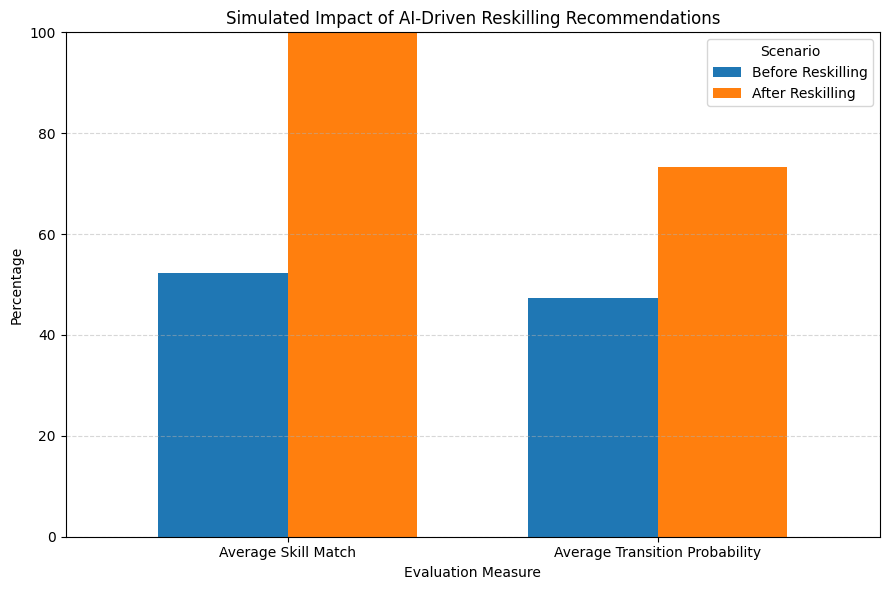

In [67]:
impact_chart_data = pd.DataFrame({
    "Before Reskilling": [
        reskilling_evaluation_df["current_skill_match"].mean(),
        reskilling_evaluation_df[
            "current_transition_probability"
        ].mean()
    ],
    "After Reskilling": [
        reskilling_evaluation_df["projected_skill_match"].mean(),
        reskilling_evaluation_df[
            "projected_transition_probability"
        ].mean()
    ]
},
index=[
    "Average Skill Match",
    "Average Transition Probability"
])

impact_chart_data.plot(
    kind="bar",
    figsize=(9, 6),
    width=0.7
)

plt.title("Simulated Impact of AI-Driven Reskilling Recommendations")
plt.xlabel("Evaluation Measure")
plt.ylabel("Percentage")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(title="Scenario")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [68]:
import joblib

# Save the trained model
joblib.dump(tuned_logistic_model, "tuned_logistic_model.pkl")

print("Model saved successfully!")

Model saved successfully!
